# DFT

DFT: [1.17683641e-14+0.00000000e+00j 5.21804822e-15-7.68829445e-15j
 7.10542736e-15+9.46465128e-15j]

Recovered: [1.8       +3.24284870e-15j 2.00345843-7.24484155e-15j
 1.12187691+2.72381953e-15j]


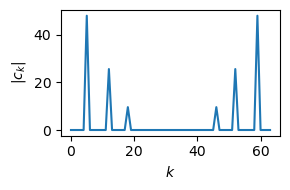

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
    N = len(y)
    c = np.zeros(N, dtype=complex)

    for k in range(N):
        s = 0
        for n in range(N):
            s = s + y[n] * np.exp(-2j * np.pi * k * n / N)
        c[k] = s
    
    return c
   
def idft(c):
    N = len(c)
    y = np.zeros(N, dtype=complex)
    
    for n in range(N):
        s = 0
        for k in range(N):
            s += c[k] * np.exp(2j * np.pi * k * n / N)
        y[n] = s / N
    
    return y

N = 64
n = np.arange(N)

y = (
    1.5 * np.cos(2 * np.pi * 5 * n / N)
    + 0.8 * np.sin(2 * np.pi * 12 * n / N)
    + 0.3 * np.cos(2 * np.pi * 18 * n / N)
)

c_vals = dft(y)
y_rec = idft(c_vals)

print(f'DFT: {c_vals[:3]}\n')
print(f'Recovered: {y_rec[:3]}')

k = np.arange(len(c_vals))

plt.figure(figsize=(3, 2))
plt.plot(k, np.abs(c_vals))
plt.xlabel(r'$k$')
plt.ylabel(r'$|c_k|$')
plt.tight_layout()
plt.show()


# FFT

Maxmium reconstruction error: 6.661e-16


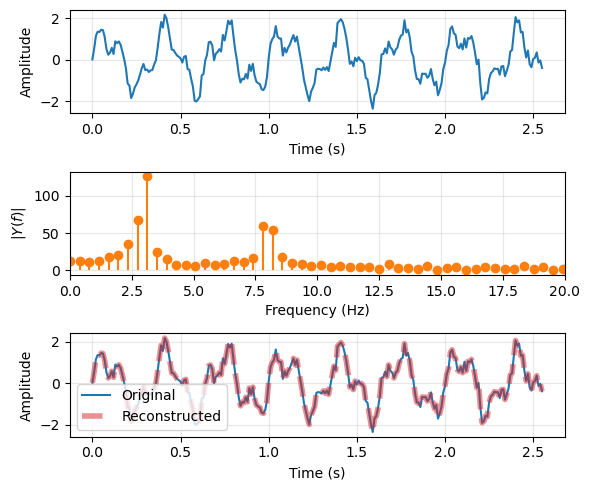

In [23]:
import numpy as np
import matplotlib.pyplot as plt

N = 256 # Number of samples
dt = 0.01 # Sampling interval
t = np.arange(N) * dt # Time axis
rng = np.random.default_rng(0) # For noise
y = (
    1.2 * np.sin(2 * np.pi * 3 * t) +    # 3 Hz component
    0.7 * np.sin(2 * np.pi * 8 * t) +    # 8 Hz component
    0.2 * rng.normal(size=N)             # small random noise
)

Y = np.fft.rfft(y)
freqs = np.fft.rfftfreq(N, d=dt)
magnitude = np.abs(Y)

y_rec = np.fft.irfft(Y, n=N)
max_error = np.max(np.abs(y - y_rec)) # Reconstruction error
print(f'Maxmium reconstruction error: {max_error:.3e}')

plt.figure(figsize=(6, 5))

# Original signal
plt.subplot(3, 1, 1)
plt.plot(t, y, color='tab:blue')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# Magnitude spectrum 
plt.subplot(3, 1, 2)
plt.stem(freqs, magnitude, basefmt=' ', linefmt='tab:orange', markerfmt='o')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$|Y(f)|$')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)  # Zoom in to the most relevant frequency range

# Original vs. reconstructed signal
plt.subplot(3, 1, 3)
plt.plot(t, y, label='Original', color='tab:blue')
plt.plot(t, y_rec, '--', label='Reconstructed', color='tab:red', alpha=0.5, lw=4)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()